В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
medical_df = pd.read_csv('medical-charges.csv') 
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [7]:
#беремо дані 
X = non_smoker_df[['age']]
y = non_smoker_df['charges']


In [8]:
#змінюємо для arrey
X = non_smoker_df['age'].values
y = non_smoker_df['charges'].values

In [9]:
X_2d = X.reshape(-1, 1)

**Метод МНК (через numpy)**

In [10]:
#Метод МНК
X_design = np.column_stack([np.ones(len(X)), X])

theta_mnk = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y)

b_mnk, w_mnk = theta_mnk
print("MNK coefficients:", b_mnk, w_mnk)

y_pred_mnk = b_mnk + w_mnk * X

rmse_mnk = np.sqrt(np.mean((y - y_pred_mnk)**2))
print("MNK RMSE:", rmse_mnk)


MNK coefficients: -2091.4205565650773 267.24891283119996
MNK RMSE: 4662.505766636395


**Full-Batch Gradient Descent (numpy)**

In [11]:
def compute_cost(X, y, b, w):
    y_pred = b + w * X
    return np.mean((y_pred - y)**2)

def gradient_descent(X, y, lr, iterations):
    b, w = 0.0, 0.0
    cost_history = []

    for i in range(iterations):
        y_pred = b + w * X
        db = np.mean(y_pred - y)
        dw = np.mean((y_pred - y) * X)

        b -= lr * db
        w -= lr * dw

        cost_history.append(compute_cost(X, y, b, w))

    return b, w, cost_history



In [12]:
learning_rates = [0.001, 0.01, 0.05]
results = {}

for lr in learning_rates:
    b, w, cost_hist = gradient_descent(X, y, lr, iterations=5000)
    results[lr] = (b, w, cost_hist)
    print(f"LR={lr}: b={b}, w={w}, final_cost={cost_hist[-1]}")


LR=0.001: b=-901.2487261550503, w=240.45149551947273, final_cost=21899412.792565044


C:\Users\karin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\karin\AppData\Local\Temp\ipykernel_416\910875642.py:3: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y)**2)
C:\Users\karin\AppData\Local\Temp\ipykernel_416\910875642.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  w -= lr * dw


LR=0.01: b=nan, w=nan, final_cost=nan
LR=0.05: b=nan, w=nan, final_cost=nan


In [13]:
learning_rates = [0.0001, 0.00005, 0.00001] #змінюємо rate щоб вплинути на масштаб даних 
results = {}

for lr in learning_rates:
    b, w, cost_hist = gradient_descent(X, y, lr, iterations=5000)
    results[lr] = (b, w, cost_hist)
    print(f"LR={lr}: b={b}, w={w}, final_cost={cost_hist[-1]}")

LR=0.0001: b=-110.42133170318685, w=222.64555257141024, final_cost=22183485.333056565
LR=5e-05: b=-53.54959940892747, w=221.36505213896004, final_cost=22209375.11044252
LR=1e-05: b=-6.879134811194853, w=220.31423923614858, final_cost=22231168.332260586


In [14]:
# Обираємо найкращий learning rate
best_lr = 0.0001   # або той, який у тебе стабільний

# Дістаємо параметри b та w з results
b_gd, w_gd, cost_hist_gd = results[best_lr]

# Рахуємо прогнози градієнтного спуску
y_pred_gd = b_gd + w_gd * X

# RMSE для градієнтного спуску
rmse_gd = np.sqrt(np.mean((y - y_pred_gd)**2))
print("GD RMSE:", rmse_gd)


GD RMSE: 4709.934748280125


**Scikit-Learn LinearRegression**

In [15]:
X_2d = non_smoker_df['age'].to_frame()
y = non_smoker_df['charges']

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_2d, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
b_skl = model.intercept_
w_skl = model.coef_[0]

print("Intercept (b):", b_skl)
print("Coefficient (w):", w_skl)


Intercept (b): -2091.4205565650846
Coefficient (w): 267.2489128311996


In [18]:
y_pred_skl = model.predict(X_2d)

In [19]:
y_pred_skl

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [20]:
rmse_skl = np.sqrt(mean_squared_error(y, y_pred_skl))
print("RMSE:", rmse_skl)


RMSE: 4662.505766636395


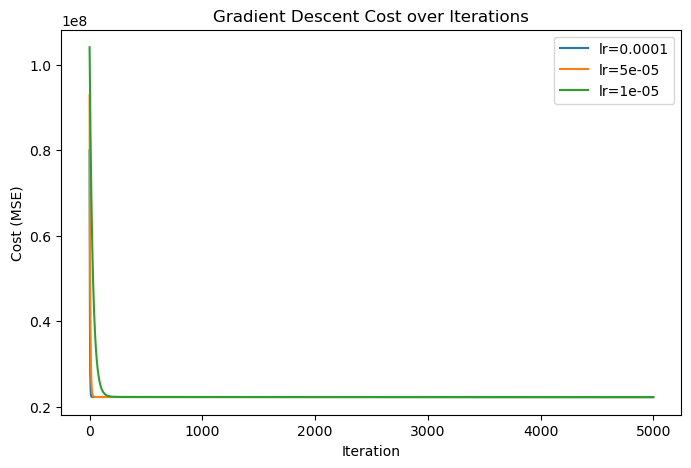

In [21]:
plt.figure(figsize=(8,5))
for lr in learning_rates:
    plt.plot(results[lr][2], label=f"lr={lr}")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Cost over Iterations")
plt.show()


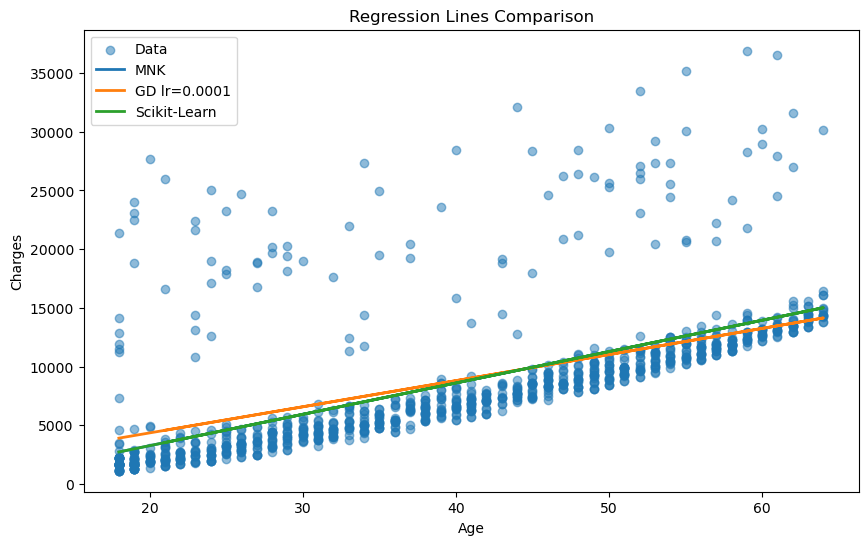

In [22]:
plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(X, y, alpha=0.5, label="Data")

# Regression lines
plt.plot(X, y_pred_mnk, label="MNK", linewidth=2)
plt.plot(X, y_pred_gd, label=f"GD lr={best_lr}", linewidth=2)
plt.plot(X, y_pred_skl, label="Scikit-Learn", linewidth=2)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Regression Lines Comparison")
plt.legend()
plt.show()


Висновок: кожен додатковий рік віку збільшує прогнозовані медичні витрати некурця приблизно на 267 доларів. Помилка приблизно 4 600 - становить приблизно 20–25% від середнього значення. Модель не ідеальна, але працює більш-менш прийнятна.

Завдання 2

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [23]:
#фільруємо курців
smoker_df = medical_df[medical_df.smoker == 'yes']


In [24]:
X_smoker = smoker_df[['age']]
y_smoker = smoker_df['charges']

In [25]:
from sklearn.linear_model import LinearRegression

model_smoker = LinearRegression()
model_smoker.fit(X_smoker, y_smoker)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
coef_smoker = model_smoker.coef_[0]
intercept_smoker = model_smoker.intercept_

coef_smoker, intercept_smoker


(np.float64(305.23760210982874), np.float64(20294.12812691597))

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_smoker = model_smoker.predict(X_smoker)
rmse_smoker = np.sqrt(mean_squared_error(y_smoker, y_pred_smoker))

rmse_smoker


np.float64(10711.00334810241)

C:\Users\karin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


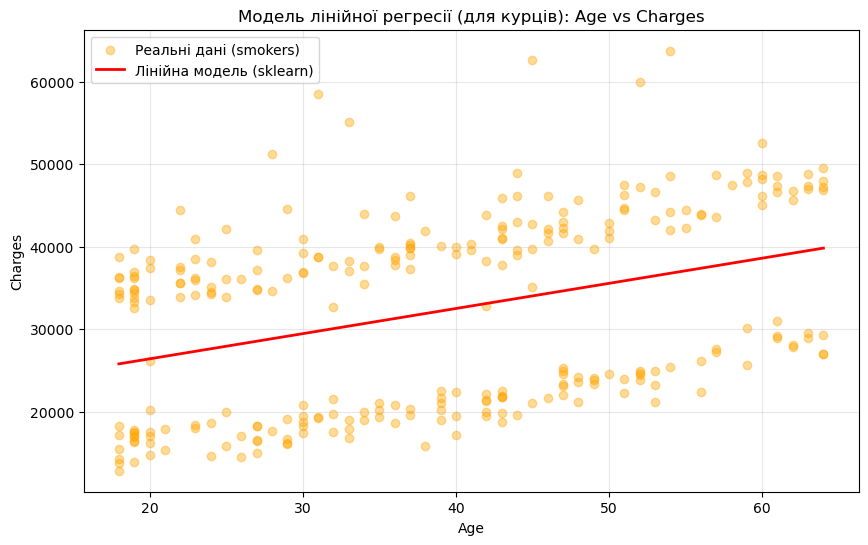

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Scatter реальних даних
plt.scatter(X_smoker, y_smoker, alpha=0.4, label='Реальні дані (smokers)', color='orange')

# Лінія регресії
age_range = np.linspace(X_smoker.min(), X_smoker.max(), 200).reshape(-1, 1)
charges_pred_line = model_smoker.predict(age_range)

plt.plot(age_range, charges_pred_line, color='red', linewidth=2, label='Лінійна модель (sklearn)')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Модель лінійної регресії (для курців): Age vs Charges')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [29]:
smoker_df['charges'].describe()


count      274.000000
mean     32050.231832
std      11541.547176
min      12829.455100
25%      20826.244213
50%      34456.348450
75%      41019.207275
max      63770.428010
Name: charges, dtype: float64

Висновок щодо трактування коефіцієнтів: кожен додатковий рік віку збільшує прогнозовані медичні витрати курця приблизно на 305 доларів. RMSE майже 10,7 тисяч доларів при std=11,5 означає, що для вхідних даних ця модель сильно помиляється. Помилка є незадовільною, модель слабка.